In [1]:
import os
import torch, torchvision
from torch import nn
from torchvision import datasets, transforms
from torchvision.models import convnext_base
from torch.utils.data import DataLoader

from collections import Counter
import gc
from time import sleep
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from IPython.display import display


#Utilities shared between models
import helpers as h

gc.collect()
torch.cuda.empty_cache()

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


# ConvNeXt-Base

## Config

In [ ]:
#Config

modelName = "ConvNext-Base"
modelPath = f"Models/{modelName}.pth"
historyPath = f"Models/{modelName}_history.csv" #recorded stats during training
statePath = f"Models/{modelName}_state.pth"  #optimizer & current epoch

purge = False   #Start a new model from scratch
training = False  #Whether to train the model or just load it

#Paralell training examples 
BATCH_SIZE = 4   #GPU a limit
#CPU workers to load data to gpu
WORKERS = 4   #Ezt még talán lehet növelni

LEARNING_RATE = 1e-3 #Lehet ki kéne próbálni 1e-4-el is
WEIGHT_DECAY = 1e-5

## Loading / initializing resources

### DataLoader and dataset parameters

In [ ]:
train_loader = h.GetTrainingDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
val_loader = h.GetValDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)
test_loader = h.GetTestDataloader(batch_size=BATCH_SIZE, num_workers=WORKERS)

ClassNames = train_loader.dataset.classes
numClasses = len(ClassNames)

print(f"Classes: {ClassNames}")
print(f"Number of classes: {numClasses}")

Classes: ['Actinic keratoses', 'Basal cell carcinoma', 'Benign keratosis-like lesions', 'Dermatofibroma', 'Melanocytic nevi', 'Melanoma', 'Squamous cell carcinoma', 'Vascular lesions']
Number of classes: 8


In [4]:
#Deriving Inverse frequency of classes to balance rare classes
totalSamples = len(train_loader.dataset) + len(test_loader.dataset) + len(val_loader.dataset)

samplesPerClass = Counter(train_loader.dataset.targets) 
samplesPerClass.update(Counter(test_loader.dataset.targets))
samplesPerClass.update(Counter(val_loader.dataset.targets))

inverseFrequencies = [ totalSamples/(numClasses * samplesPerClass[i]) for i in range(numClasses) ]
#freqvInv = [3.652, 0.953, 1.207, 13.248, 0.246, 0.700, 5.042, 12.515]  #from excel
print(inverseFrequencies)

[3.652104959630911, 0.9528663857959675, 1.2066977896341464, 13.248430962343097, 0.24593203883495146, 0.7002156125608138, 5.041998407643312, 12.515316205533598]


### Model

In [5]:
#Model definition
model = convnext_base(weights=None)
model.classifier[2] = nn.Linear(model.classifier[2].in_features, out_features=numClasses)

### Loss function and optimizer

In [ ]:
#LossFN and Optimizer
#criterion = nn.CrossEntropyLoss()
criterion = nn.CrossEntropyLoss(weight=torch.tensor(inverseFrequencies))
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

### Loading if available

In [7]:
#Loading or initializing model and statistics

epochs_done = 0
history = None

if not purge and os.path.exists(modelPath):
    model.load_state_dict(torch.load(modelPath))    #this loads latest model, not bestVal
    state = torch.load(statePath)
    optimizer.load_state_dict(state["optimizer"])
    epochs_done = state["epoch"]
    #load recorded stats too
    history = pd.read_csv(historyPath)
    print("Loaded last state")


Loaded last state


## Training

In [8]:
model = model.to(device)
criterion = criterion.to(device)

In [9]:
if training:
    bestTrainAcc = 0.0
    bestValAcc = 0.0
    if history is not None and len(history) > 0:
        bestTrainAcc = history["train_acc"].max()
        bestValAcc = history["val_acc"].max()

    for epoch in range(epochs_done, 50):
        #Executing training and validation
        #train_loss, train_acc = 0,0
        train_loss, train_acc = h.trainingEpoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, CM = h.validate(model, val_loader, criterion, device)

        print(
            f"Epoch {epoch+1}/{h.MAX_EPOCHS} | "
            f"train loss: {train_loss:.4f}, train acc: {train_acc:.4f} | "
            f"val loss: {val_loss:.4f}, val acc: {val_acc:.4f}"
        )
        epochs_done += 1

        #Recording statistics
        sampleRow = {
            "epoch": epoch+1, "train_loss": train_loss, "train_acc": train_acc, "val_loss": val_loss, "val_acc": val_acc
        }
        sampleRow.update(h.FlattenCM(CM))
        if history is None:
            history = pd.DataFrame(columns=sampleRow.keys())
        history.loc[len(history)] = sampleRow

        #Saving snapshot
        torch.save(model.state_dict(), modelPath)
        torch.save({
                "epoch": epoch+1,
                "optimizer": optimizer.state_dict()
            }, statePath)        
        history.to_csv(historyPath, index=False)

        #saving best model
        if val_acc > bestValAcc:
            bestValAcc = val_acc
            torch.save(model.state_dict(), f"Models/{modelName}_bestVal.pth")
        
        if epoch == h.MAX_EPOCHS-1: break
        print("Letting GPU cool...")
        sleep(180) #Let GPU cool a little

else:
    print("Already trained")

display(history)

Already trained


,epoch,train_loss,train_acc,val_loss,val_acc,cm_true_Actinic keratoses_pred_Actinic keratoses,cm_true_Basal cell carcinoma_pred_Actinic keratoses,cm_true_Benign keratosis-like lesions_pred_Actinic keratoses,cm_true_Dermatofibroma_pred_Actinic keratoses,cm_true_Melanocytic nevi_pred_Actinic keratoses,...,cm_true_Squamous cell carcinoma_pred_Squamous cell carcinoma,cm_true_Vascular lesions_pred_Squamous cell carcinoma,cm_true_Actinic keratoses_pred_Vascular lesions,cm_true_Basal cell carcinoma_pred_Vascular lesions,cm_true_Benign keratosis-like lesions_pred_Vascular lesions,cm_true_Dermatofibroma_pred_Vascular lesions,cm_true_Melanocytic nevi_pred_Vascular lesions,cm_true_Melanoma_pred_Vascular lesions,cm_true_Squamous cell carcinoma_pred_Vascular lesions,cm_true_Vascular lesions_pred_Vascular lesions
0,1,1.911276,0.399319,1.774278,0.159747,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,1.748132,0.453608,1.376200,0.514037,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,1.680800,0.474830,1.329065,0.529063,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,1.648331,0.484552,1.353933,0.499407,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,1.623670,0.501530,1.307995,0.531831,28,61,9,1,13,...,0,0,7,33,16,8,28,1,4,8
5,6,1.596098,0.505429,1.298236,0.540530,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
6,7,1.580720,0.518359,1.319425,0.533412,0,0,0,0,0,...,0,0,1,5,1,1,18,0,1,9
7,8,1.555770,0.527391,1.284544,0.542507,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,6
8,9,1.525783,0.528181,1.150496,0.578885,0,1,2,0,0,...,0,0,0,0,1,0,3,0,0,9
9,10,1.504856,0.539828,1.318830,0.537367,0,0,0,0,0,...,8,0,0,5,2,0,20,4,1,17


In [10]:
#latest CM
CM = h.ParseCM(history.iloc[-1][5:])
#display(history)
display(CM)

,Actinic keratoses,Basal cell carcinoma,Benign keratosis-like lesions,Dermatofibroma,Melanocytic nevi,Melanoma,Squamous cell carcinoma,Vascular lesions
Actinic keratoses,16,10,17,0,5,7,1,0
Basal cell carcinoma,50,253,43,3,43,41,33,1
Benign keratosis-like lesions,16,27,107,3,89,54,8,0
Dermatofibroma,0,5,6,11,7,2,2,0
Melanocytic nevi,0,13,44,3,965,87,1,2
Melanoma,4,17,43,2,172,256,8,0
Squamous cell carcinoma,0,4,1,0,2,4,8,0
Vascular lesions,0,3,1,1,4,1,1,22


## Progress trough training

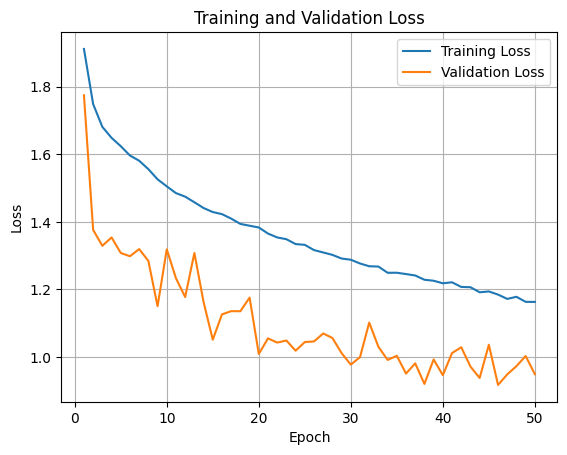

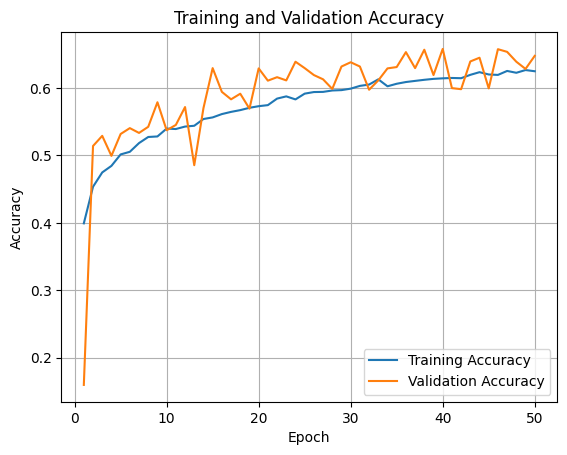

In [11]:
plt.figure()
plt.plot(history["epoch"], history["train_loss"], label="Training Loss")
plt.plot(history["epoch"], history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure()
plt.plot(history["epoch"], history["train_acc"], label="Training Accuracy")
plt.plot(history["epoch"], history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.show()

## Trying out trained model

In [12]:
#Testing should be done on best performing model

mpath = f"Models/{modelName}_bestVal.pth" #with best validation
mpath = f"Models/{modelName}.pth" #latest model

model.load_state_dict(torch.load(mpath))

<All keys matched successfully>

### Evaluate on test set

In [13]:
model = model.to(device)

test_loss, test_acc, TEST_CM = h.validate(model, test_loader, criterion, device)

print(f"test loss: {test_loss:.4f}, test acc: {test_acc:.4f}")

test loss: 0.9654, test acc: 0.6280


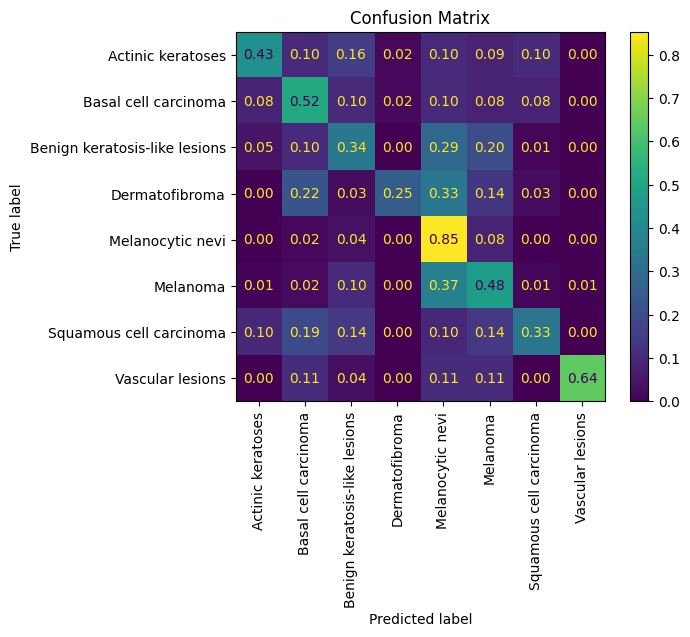

In [37]:
TEST_CM = TEST_CM.apply(pd.to_numeric)

cm_norm = TEST_CM.div(TEST_CM.sum(axis=1), axis=0)

disp = ConfusionMatrixDisplay(
    display_labels=cm_norm.index,
    confusion_matrix=cm_norm.values
)


disp.plot(values_format=".2f")
plt.title("Confusion Matrix")
plt.xticks(rotation=90)
plt.show()

### Deriving per class metrics

In [17]:
metrics = {}

for className in TEST_CM.index:
    TP, FN, FP, TN = h.PredictionsPerClass(TEST_CM, className)
    accuracy, precision, recall, f1 = h.ClassMetrics(TP, FN, FP, TN)
    metrics[className] = {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
metrics = pd.DataFrame(metrics).T
display(metrics)

,accuracy,precision,recall,f1
Actinic keratoses,0.009843,0.431034,0.284091,0.342466
Basal cell carcinoma,0.098031,0.518750,0.747748,0.612546
Benign keratosis-like lesions,0.040945,0.340984,0.395437,0.366197
Dermatofibroma,0.003543,0.250000,0.360000,0.295082
Melanocytic nevi,0.370472,0.852355,0.730590,0.786789
Melanoma,0.095276,0.476378,0.534216,0.503642
Squamous cell carcinoma,0.002756,0.333333,0.109375,0.164706
Vascular lesions,0.007087,0.642857,0.692308,0.666667


### Inspecting with captum

Examining what features are relevant

### Demo

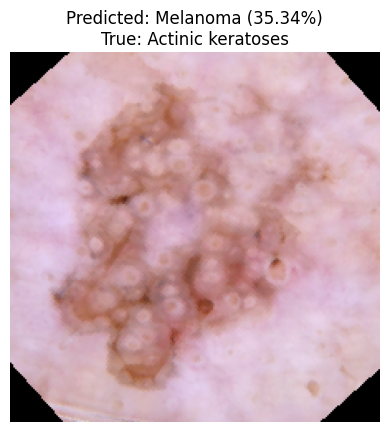

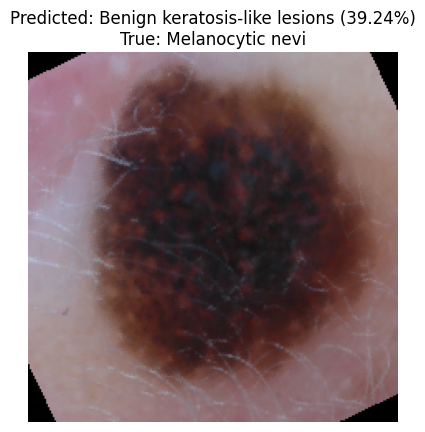

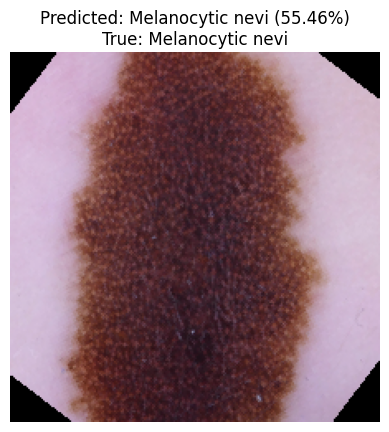

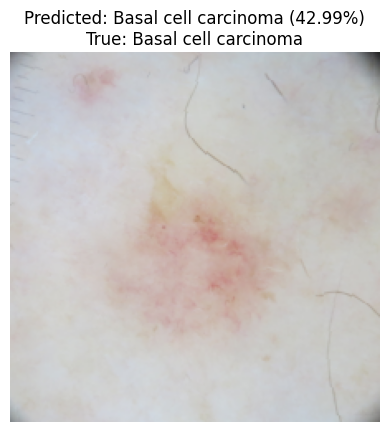

In [36]:
model.eval()

images, labels = next(iter(train_loader))
images, labels = images.to(device), labels.to(device)
with torch.no_grad():
    logits = model(images)
    probs = torch.softmax(logits, dim=1)
    preds = torch.argmax(probs, dim=1)


for idx in range(len(preds)):
    img = images[idx].cpu()
    true_label = ClassNames[labels[idx].item()]
    pred_label = ClassNames[preds[idx].item()]
    confidence = probs[idx, preds[idx]].item()

    # If image was normalized, unnormalize it before plotting
    mean = torch.tensor(h.MEAN).view(3, 1, 1)
    std = torch.tensor(h.STD).view(3, 1, 1)

    img = img * std + mean
    img = img.clamp(0, 1)

    plt.imshow(img.permute(1, 2, 0))
    plt.axis("off")
    plt.title(
    f"Predicted: {pred_label} ({confidence:.2%})\n"
    f"True: {true_label}"
    )
    plt.show()

